In [94]:
##import library
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score , mean_squared_error
from sklearn.ensemble import RandomForestRegressor

In [75]:
##load dataset
path = "C:/Users/Admin/Documents/ASSIGNMENTS/ToyotaCorolla.csv"
df = pd.read_csv(path,encoding='latin1')
print(df.head())

   Id                                           Model  Price  Age_08_04  \
0   1   TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors  13500         23   
1   2   TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors  13750         23   
2   3   TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors  13950         24   
3   4   TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors  14950         26   
4   5     TOYOTA Corolla 2.0 D4D HATCHB SOL 2/3-Doors  13750         30   

   Mfg_Month  Mfg_Year     KM Fuel_Type  HP  Met_Color  ... Central_Lock  \
0         10      2002  46986    Diesel  90          1  ...            1   
1         10      2002  72937    Diesel  90          1  ...            1   
2          9      2002  41711    Diesel  90          1  ...            0   
3          7      2002  48000    Diesel  90          0  ...            0   
4          3      2002  38500    Diesel  90          0  ...            1   

   Powered_Windows  Power_Steering  Radio  Mistlamps  Sport_Model  \
0                1     

In [76]:
df.shape

(1436, 38)

In [77]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 38 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Id                1436 non-null   int64 
 1   Model             1436 non-null   object
 2   Price             1436 non-null   int64 
 3   Age_08_04         1436 non-null   int64 
 4   Mfg_Month         1436 non-null   int64 
 5   Mfg_Year          1436 non-null   int64 
 6   KM                1436 non-null   int64 
 7   Fuel_Type         1436 non-null   object
 8   HP                1436 non-null   int64 
 9   Met_Color         1436 non-null   int64 
 10  Color             1436 non-null   object
 11  Automatic         1436 non-null   int64 
 12  cc                1436 non-null   int64 
 13  Doors             1436 non-null   int64 
 14  Cylinders         1436 non-null   int64 
 15  Gears             1436 non-null   int64 
 16  Quarterly_Tax     1436 non-null   int64 
 17  Weight        

In [78]:
df.isna().sum()

Id                  0
Model               0
Price               0
Age_08_04           0
Mfg_Month           0
Mfg_Year            0
KM                  0
Fuel_Type           0
HP                  0
Met_Color           0
Color               0
Automatic           0
cc                  0
Doors               0
Cylinders           0
Gears               0
Quarterly_Tax       0
Weight              0
Mfr_Guarantee       0
BOVAG_Guarantee     0
Guarantee_Period    0
ABS                 0
Airbag_1            0
Airbag_2            0
Airco               0
Automatic_airco     0
Boardcomputer       0
CD_Player           0
Central_Lock        0
Powered_Windows     0
Power_Steering      0
Radio               0
Mistlamps           0
Sport_Model         0
Backseat_Divider    0
Metallic_Rim        0
Radio_cassette      0
Tow_Bar             0
dtype: int64

In [79]:
df.columns

Index(['Id', 'Model', 'Price', 'Age_08_04', 'Mfg_Month', 'Mfg_Year', 'KM',
       'Fuel_Type', 'HP', 'Met_Color', 'Color', 'Automatic', 'cc', 'Doors',
       'Cylinders', 'Gears', 'Quarterly_Tax', 'Weight', 'Mfr_Guarantee',
       'BOVAG_Guarantee', 'Guarantee_Period', 'ABS', 'Airbag_1', 'Airbag_2',
       'Airco', 'Automatic_airco', 'Boardcomputer', 'CD_Player',
       'Central_Lock', 'Powered_Windows', 'Power_Steering', 'Radio',
       'Mistlamps', 'Sport_Model', 'Backseat_Divider', 'Metallic_Rim',
       'Radio_cassette', 'Tow_Bar'],
      dtype='object')

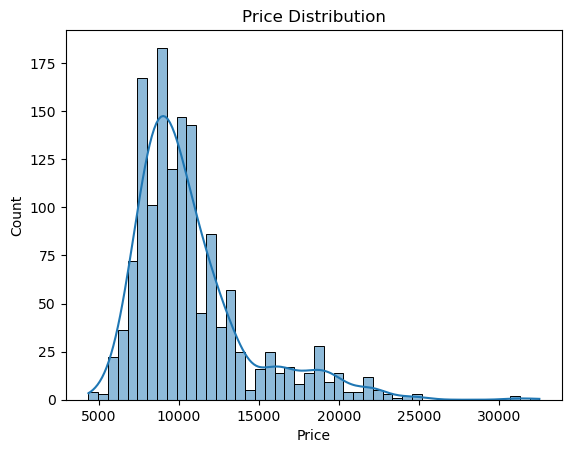

In [80]:
# Analyze distribution of Price
sns.histplot(df['Price'], kde=True)
plt.title("Price Distribution")
plt.show()

# Observation:
 Most car prices are concentrated between 7000 and 12000 euros.
 The distribution is right-skewed, meaning there are a few cars with very high prices.
 This indicates presence of outliers (expensive cars).

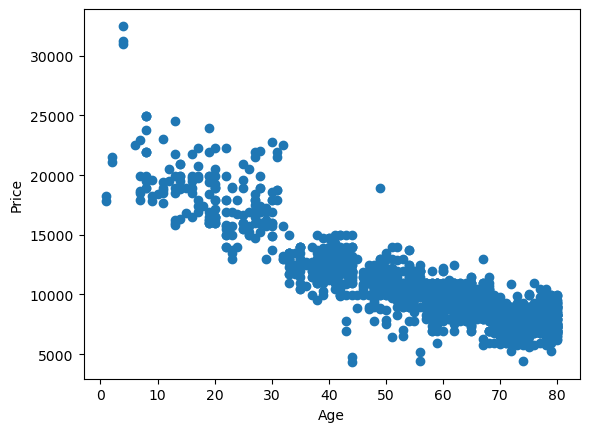

In [82]:
plt.scatter(df['Age_08_04'], df['Price'])
plt.xlabel("Age")
plt.ylabel("Price")
plt.show()

# Observation:
 There is a clear negative relationship between Age and Price.
 As the age of the car increases, the price decreases.
 This indicates that Age is an important feature for predicting price.
 Some outliers are present with very high prices.

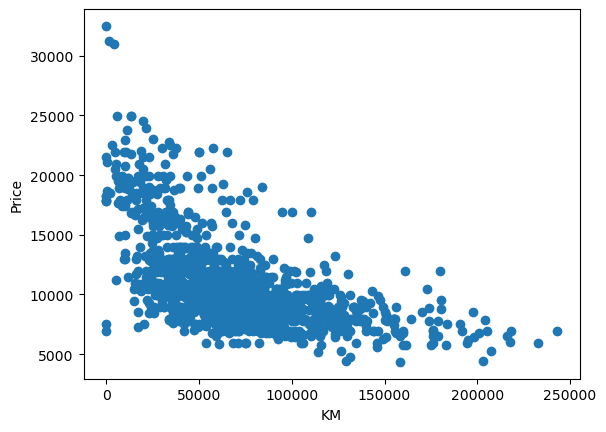

In [83]:
plt.scatter(df['KM'], df['Price'])
plt.xlabel("KM")
plt.ylabel("Price")
plt.show()

# Observation:
 There is a negative relationship between KM and Price.
 As the kilometers driven increases, the price decreases.
 Cars with lower KM tend to have higher prices.
 This indicates KM is an important feature for prediction.

In [84]:
# Drop unnecessary columns
df = df.drop(['Id' , 'Color' , 'Model'], axis = 1)
df.head(2)

,Price,Age_08_04,Mfg_Month,Mfg_Year,KM,Fuel_Type,HP,Met_Color,Automatic,cc,...,Central_Lock,Powered_Windows,Power_Steering,Radio,Mistlamps,Sport_Model,Backseat_Divider,Metallic_Rim,Radio_cassette,Tow_Bar
0,13500,23,10,2002,46986,Diesel,90,1,0,2000,...,1,1,1,0,0,0,1,0,0,0
1,13750,23,10,2002,72937,Diesel,90,1,0,2000,...,1,0,1,0,0,0,1,0,0,0


In [85]:
df.Fuel_Type.unique()

array(['Diesel', 'Petrol', 'CNG'], dtype=object)

In [86]:
# Convert categorical to numeric
df = pd.get_dummies(df,columns = ['Fuel_Type'], drop_first = True)

In [87]:
df.head()

,Price,Age_08_04,Mfg_Month,Mfg_Year,KM,HP,Met_Color,Automatic,cc,Doors,...,Power_Steering,Radio,Mistlamps,Sport_Model,Backseat_Divider,Metallic_Rim,Radio_cassette,Tow_Bar,Fuel_Type_Diesel,Fuel_Type_Petrol
0,13500,23,10,2002,46986,90,1,0,2000,3,...,1,0,0,0,1,0,0,0,True,False
1,13750,23,10,2002,72937,90,1,0,2000,3,...,1,0,0,0,1,0,0,0,True,False
2,13950,24,9,2002,41711,90,1,0,2000,3,...,1,0,0,0,1,0,0,0,True,False
3,14950,26,7,2002,48000,90,0,0,2000,3,...,1,0,0,0,1,0,0,0,True,False
4,13750,30,3,2002,38500,90,0,0,2000,3,...,1,0,1,0,1,0,0,0,True,False


In [88]:
##split X and y
X = df.drop('Price', axis=1)
y = df['Price']

In [89]:
X.head()

,Age_08_04,Mfg_Month,Mfg_Year,KM,HP,Met_Color,Automatic,cc,Doors,Cylinders,...,Power_Steering,Radio,Mistlamps,Sport_Model,Backseat_Divider,Metallic_Rim,Radio_cassette,Tow_Bar,Fuel_Type_Diesel,Fuel_Type_Petrol
0,23,10,2002,46986,90,1,0,2000,3,4,...,1,0,0,0,1,0,0,0,True,False
1,23,10,2002,72937,90,1,0,2000,3,4,...,1,0,0,0,1,0,0,0,True,False
2,24,9,2002,41711,90,1,0,2000,3,4,...,1,0,0,0,1,0,0,0,True,False
3,26,7,2002,48000,90,0,0,2000,3,4,...,1,0,0,0,1,0,0,0,True,False
4,30,3,2002,38500,90,0,0,2000,3,4,...,1,0,1,0,1,0,0,0,True,False


In [90]:
###train the model

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.2 , random_state = 42)

In [91]:
model = LinearRegression()
model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [92]:
#prediction
y_pred = model.predict(X_test)

In [93]:
##evaluate
# RMSE is used instead of MSE because it is in the same unit as the target variable (Price).
# It is easier to interpret the average prediction error in euros.
print('r2 Score:', r2_score(y_test,y_pred))
print('RMSE:' , np.sqrt(mean_squared_error(y_test,y_pred)))

r2 Score: 0.8874627529115947
RMSE: 1225.3818690318883


#observation
         The Linear Regression model achieved an R2 score of 0.89,
         indicating strong predictive performance.
         The RMSE is approximately 1225 euros, meaning the model's
         predictions are on average off by around €1200.
         This is acceptable given the price range of the cars.

In [102]:
rf = RandomForestRegressor(n_estimators = 200, random_state= 42)
rf.fit(X_train,y_train)
y_pred_rf = rf.predict(X_test)

In [103]:
print('r2 Score:' , r2_score(y_test,y_pred_rf))
print('RMSE:', np.sqrt(mean_squared_error(y_test, y_pred_rf)))

r2 Score: 0.9299984578475969
RMSE: 966.4449263527661


In [ ]:
# Random Forest Regressor outperformed Linear Regression.
# It achieved a higher R2 score (0.93) and lower RMSE (~966 euros).
# This indicates better prediction accuracy.
# Random Forest captures non-linear relationships more effectively.

In [ ]:
# Conclusion:
# Linear Regression provided a good baseline model.
# However, Random Forest Regressor significantly improved performance.
# Therefore, Random Forest is selected as the final model for car price prediction.